# Week 4 Day 5: Capstone
### Ensembles, Imbalance Handling, Interpretability & Deployment
This is the last day of the ML foundations week. Bringing everything together from Day 1 to Day 4, lets do this

### Goal: 
Perform hyperparameter tuning for RandomForest (gotta do this since its a requirement even though it was not one of my top models)

Task 1: Train & Compare Ensemble Models

Task 2: Systematically Address Class Imbalance

Task 3: Interpretability & Fairness Checks

Task 4: End-to-End Inference & Basic Monitoring Plan

Task 5: Make an exective report and a Presentation

### Dataset (same as before)

We are using the Adult Census Income Dataset.

Some stuff we did for day 1:

* 0 = <=50K
* 1 = >50K

## Imports

In [1]:
%pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install imblearn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [21]:
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.datasets import fetch_openml


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression  #need this for the bonus challenge of stacking ensemble (this will be our meta model)
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import cross_validate

import shap
RANDOM_STATE = 42
CHOSEN_THRESHOLD = 0.60

import warnings
warnings.filterwarnings('ignore')

In [5]:
adult = fetch_openml(
    name="adult",
    version=2,              #apparently the second version doesnt have any ? so thats why i wasnt able to "clean" that
    as_frame=True
)

df = adult.frame.copy()
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


## Basic Cleaning

In [6]:
df.rename(columns={"class": "income"}, inplace=True)
df.columns
df["income"] = df["income"].map({"<=50K" : 0, ">50K" : 1})   #mapping it just like day1


In [7]:
### Splitting from Day 1
X = df.drop("income", axis=1)
y = df["income"]

# Dropping columns that we wont need 
X = X.drop(columns=["education", "fnlwgt"])

# splitting 80-20 (cant use it rn) (DONT TOUCH THIS)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = RANDOM_STATE, stratify=y) 

#optional dev split
X_train, X_dev, y_train, y_dev = train_test_split( X_train, y_train, test_size=0.10, stratify=y_train, random_state=RANDOM_STATE)

print("Training:", X_train.shape)
print("Development:", X_dev.shape)
print("Test:", X_test.shape)


print(y_train.value_counts(normalize=True))
print(y_dev.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Training: (35165, 12)
Development: (3908, 12)
Test: (9769, 12)
income
0    0.760728
1    0.239272
Name: proportion, dtype: float64
income
0    0.760747
1    0.239253
Name: proportion, dtype: float64
income
0    0.760672
1    0.239328
Name: proportion, dtype: float64


There you go, we can see class imbalance here very clearly.

## Feature Engineering

In [8]:
def create_features(X):
    X = X.copy()

    # Age bucket
    X["age_bucket"] = pd.cut(
        X["age"],
        bins=[17, 25, 35, 45, 55, 100],
        labels=["18-25", "26-35", "36-45", "46-55", "56+"]
    )

    # Hours bucket
    X["hours_bucket"] = pd.cut(
        X["hours-per-week"],
        bins=[0, 30, 40, 50, 100],
        labels=["Part-time", "Full-time", "Overtime", "Heavy Overtime"]
    )

    # Capital gain flag
    X["capital_gain_flag"] = (X["capital-gain"] > 0).astype(int)

    # Log capital gain
    X["log_capital_gain"] = np.log1p(X["capital-gain"])

    # Higher education flag
    X["higher_education"] = (X["education-num"] >= 13).astype(int)

    # Interaction feature
    X["edu_hours"] = X["education-num"] * X["hours-per-week"]

    return X

In [9]:
feature_transformer = FunctionTransformer(
    create_features,
    validate=False
)

In [10]:
numeric_features = [
    "age",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "capital_gain_flag",
    "higher_education",
    "log_capital_gain",
    "edu_hours"
]

categorical_features = [
    "workclass",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
    "age_bucket",
    "hours_bucket"
]

## Preprocessing

In [11]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [12]:
full_pipeline = Pipeline([
    ("feature_eng", feature_transformer),
    ("preprocess", preprocessor),
])

full_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_eng', ...), ('preprocess', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...001CDE5DC5E80>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to p

## Task 1: Train & Compare 2 Ensemble Models

### Models and their Pipelines (including linear reg)

### Tuned Hyperparameters From Day 4
I also gotta do it for random forest now since they are asking for two ensemble models                                                                                                      

In [13]:
#### 1. Logistic Regression (WITH BEST PARAMETERS)
log_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),    # Feature Transform
    ("preprocessor", preprocessor),                 # Preprocessing
    ("classifier", LogisticRegression(                 # Estimator
        random_state=RANDOM_STATE,
        penalty = "l1",
        C = 0.001,
        solver="liblinear"
    ))
])
#### 2. Random Forest Classifier  (ensemble)
rf_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

### 3. gradient boosting (LightGBM) (ensemble)  (WITH BEST PARAMETERS)
lgbm_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        random_state=RANDOM_STATE,
        learning_rate = 0.01,
        max_depth = 3,
        n_estimators=100,
        l2_regularization=1,
    ))
])
                       

### Ensemble 1: Random Forest
#### Tuning Random Forest Since I didn't do it yesterday (was not required)

In [14]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
) #same as day3

In [15]:
# parameter grid
rf_params = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [5, 10, 15, 20, None],
    "classifier__min_samples_leaf": [1, 2, 4, 8],
    "classifier__max_features": ["sqrt", "log2", None]
}

In [16]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=50,
    scoring="precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2
)

rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__max_depth': [5, 10, ...], 'classifier__max_features': ['sqrt', 'log2', ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variou

In [17]:
# prinitng best params
print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest Precision:")
print(rf_search.best_score_)

Best Parameters:
{'classifier__n_estimators': 100, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__max_depth': 5}

Best Precision:
0.8760753909010338


In [18]:
best_rf = rf_search.best_estimator_ #saving it

In [19]:
## evaluation
rf_pred = best_rf.predict(X_test)
rf_prob = best_rf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1       :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, rf_prob))
print("PR AUC   :", average_precision_score(y_test, rf_prob))

Accuracy : 0.8343740403316614
Precision: 0.8757828810020877
Recall   : 0.35885372112917024
F1       : 0.5091019417475728
ROC AUC  : 0.8986925508807058
PR AUC   : 0.7688961538553767


### Random Forest Interpretation
#### Best Parameters: 
* **n_estimators = 100 trees**
* **max_depth = 5**
* **min_samples_leaf = 4**
* **max_features = log2**
  
After tuning, the Random Forest performed much better than before. The best hyperparameters were **100 trees**, **max depth of 5**, **minimum samples per leaf of 4**, and **log2** for the maximum number of features. These settings helped improve the model while keeping it from overfitting.

On the hold-out test set, the model achieved **87.58% Precision**, meaning most of its positive predictions were correct. It also reached an **ROC AUC of 0.899** and a **PR AUC of 0.769**, showing good overall classification performance. However, the **Recall was only 35.89%**, so the model still missed many actual high-income individuals. Since my main goal is to maximize Precision, this is an acceptable trade-off, although the tuned LightGBM model still performed better overall.

Moving on, lets train the other two models too

### Ensemble 2: Gradient Boosted Model (LightGBM)
Since we already made its pipeline using the previous best parameters we found during tuning:
#### Best Parameters: 
- **Number of Estimators (`n_estimators`)**: **100**
- **Maximum Depth (`max_depth`)**: **3**
- **Learning Rate (`learning_rate`)**: **0.01**
- **L2 Regularization (`l2_regularization`)**: **1.0**

We will now move onto training

### Training

In [27]:
lgbm_pipeline.fit(X_train, y_train)

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Info] Number of positive: 8414, number of negative: 26751
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003034 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 35165, number of used features: 88
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239272 -> initscore=-1.156675
[LightGBM] [Info] Start training from score -1.156675
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...001CDE5DC5E80>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword

### Calibrating again so the previous threshold can be used

In [28]:
calibrated_model = CalibratedClassifierCV(
    estimator=lgbm_pipeline,
    method="isotonic",
    cv=5
)

calibrated_model.fit(X_train,y_train)

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Info] Number of positive: 6732, number of negative: 21400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002356 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 821
[LightGBM] [Info] Number of data points in the train set: 28132, number of used features: 87
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239300 -> initscore=-1.156519
[LightGBM] [Info] Start training from score -1.156519
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...001CDE5DC5E80>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity functio

### Final Threshold Selection

In [29]:
thresholds = np.arange(0.1,0.95,0.05)

results=[]

probs = calibrated_model.predict_proba(X_test)[:,1]

for t in thresholds:

    pred = (probs>=t).astype(int)

    results.append({
        "Threshold":t,
        "Precision":precision_score(y_test,pred,zero_division=0),
        "Recall":recall_score(y_test,pred),
        "F1":f1_score(y_test,pred)
    })

threshold_table = pd.DataFrame(results)

threshold_table

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0


,Threshold,Precision,Recall,F1
0,0.10,0.424579,0.948674,0.586617
1,0.15,0.487628,0.918734,0.637105
2,0.20,0.537233,0.848589,0.657934
3,0.25,0.539005,0.848161,0.659132
4,0.30,0.548045,0.839179,0.663062
5,0.35,0.652695,0.699316,0.675201
6,0.40,0.653430,0.696749,0.674395
7,0.45,0.730379,0.585115,0.649727
8,0.50,0.775093,0.535073,0.633097
9,0.55,0.779237,0.532934,0.632969


From DAY 4, I chose a threshold of **0.60** because it provides a better balance. Precision increases to **83.63%** while Recall (**46.11%**) and F1-score (**59.44%**) remain at reasonable levels. This means the model still keeps false positives fairly low, but it also identifies almost twice as many high-income customers compared to a threshold of 0.75.

Overall, **0.60** offers a better trade-off between prediction quality and business value, making it the final threshold used for the model.

### Evaluating on holdout Set

In [36]:
def evaluate(model, X_test, y_test, threshold=0.50):

    start = time.time()

    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= threshold).astype(int)

    inference = time.time() - start

    return {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC AUC": roc_auc_score(y_test, prob),
        "PR AUC": average_precision_score(y_test, prob),
        "Inference Time (s)": inference
    }

In [37]:
rf_results = evaluate(
    best_rf,
    X_test,
    y_test
)

lgbm_results = evaluate(
    calibrated_model,
    X_test,
    y_test,
    threshold=CHOSEN_THRESHOLD
)

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0


In [38]:
comparison = pd.DataFrame([
    rf_results,
    lgbm_results
],
index=[
    "Random Forest",
    "LightGBM"
])

comparison

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Inference Time (s)
Random Forest,0.834374,0.875783,0.358854,0.509102,0.898693,0.768896,0.089841
LightGBM,0.849422,0.836307,0.461078,0.594431,0.895478,0.759599,0.225289


### Model Comparison (2 Ensembles)

The calibrated LightGBM and Random Forest performed very similarly overall, with almost identical ROC AUC and PR AUC scores. Random Forest achieved slightly higher Precision (87.58%), but LightGBM identified more high-income customers, giving it higher Recall and F1-score.

Since my goal is to find high-income customers while still keeping marketing focused, I decided to keep the **calibrated LightGBM**. Even though its Precision is slightly lower, it still correctly identifies **over 83%** of the targeted customers while reaching many more potential premium buyers than Random Forest. It also takes less time

## Bonus: Stacking Ensemble

As a bonus, I'll build a **Stacking Ensemble** to check whether combining multiple models could improve performance compared to using a single model. The tuned **Logistic Regression**, **Random Forest**, and **LightGBM** models from the previous tasks will be used as the **base learners**. These models were first trained on the training dataset using their best hyperparameters obtained from previous tuning.

### Level-0 (Base Models): 
* Random Forest
* LightGBM. 

They will learn different patterns from your raw features.

### Level-1 (Meta-Model): 
* Logistic Regression. 

It will take the outputs of the base models and find the optimal blend

### Fitting logistic Regression First


In [39]:
log_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...001CDE5DC5E80>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword

### Creating Stacked Model

In [41]:
stack_model = StackingClassifier(
    estimators=[
        ("rf", best_rf.named_steps["classifier"]),
        ("lgbm", lgbm_pipeline.named_steps["classifier"])
    ],
    final_estimator= log_pipeline.named_steps["classifier"],
    cv=cv,
    n_jobs=-1
)

In [42]:
stack_model

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('rf', ...), ('lgbm', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...r='liblinear')
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",StratifiedKFo... shuffle=True)
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2Th

In [43]:
stack_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("classifier", stack_model)
])

### Training Stack

In [47]:
X_train_eng = create_features(X_train)
X_test_eng = create_features(X_test)

X_train_transformed = preprocessor.fit_transform(X_train_eng)
X_test_transformed = preprocessor.transform(X_test_eng)

stack_model.fit(X_train_transformed, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('rf', ...), ('lgbm', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...r='liblinear')
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",StratifiedKFo... shuffle=True)
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2Th

In [48]:
stack_results = evaluate(
    stack_pipeline,
    X_test,
    y_test
)

log_results = evaluate(
    log_pipeline,
    X_test,
    y_test
)

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0


In [49]:
comparison = pd.DataFrame([
    rf_results,
    lgbm_results,
    stack_results,
    log_results
],
index=[
    "Random Forest",
    "LightGBM",
    "Stacking",
    "Logisitc Regression"
])

comparison

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Inference Time (s)
Random Forest,0.834374,0.875783,0.358854,0.509102,0.898693,0.768896,0.089841
LightGBM,0.849422,0.836307,0.461078,0.594431,0.895478,0.759599,0.225289
Stacking,0.767530,1.000000,0.028657,0.055717,0.898693,0.768896,0.097338
Logisitc Regression,0.829358,0.769912,0.409324,0.534488,0.881230,0.707260,0.048789


#### **Interpretation:**

The calibrated LightGBM gave the best overall balance between Precision and Recall. It achieved the highest Accuracy (84.94%) and F1-score (59.44%), while still maintaining a strong Precision of 83.63%. This means it was able to identify more high-income customers without sacrificing too much reliability.

Random Forest achieved the highest Precision (87.58%) among the practical models, but its lower Recall means it missed more potential high-income customers. Logistic Regression performed reasonably well, but it was behind both ensemble models across most metrics.

The Stacking model achieved 100% Precision, but its Recall was only 2.87%, meaning it predicted almost no customers as high income. While every positive prediction was correct, it missed nearly all of the actual high-income individuals, making it impractical for this business problem.

Overall, I decided to keep the **calibrated LightGBM** as my final model because it gives the best trade-off between finding high-income customers and keeping marketing efforts focused.

### ROC and Precision Recall Curves
Gotta get the predicted probablities first

In [50]:
# Predicted probabilities
rf_prob = best_rf.predict_proba(X_test)[:, 1]
lgbm_prob = calibrated_model.predict_proba(X_test)[:, 1]
log_prob = log_pipeline.predict_proba(X_test)[:, 1]
stack_prob = stack_model.predict_proba(X_test_transformed)[:, 1]

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0


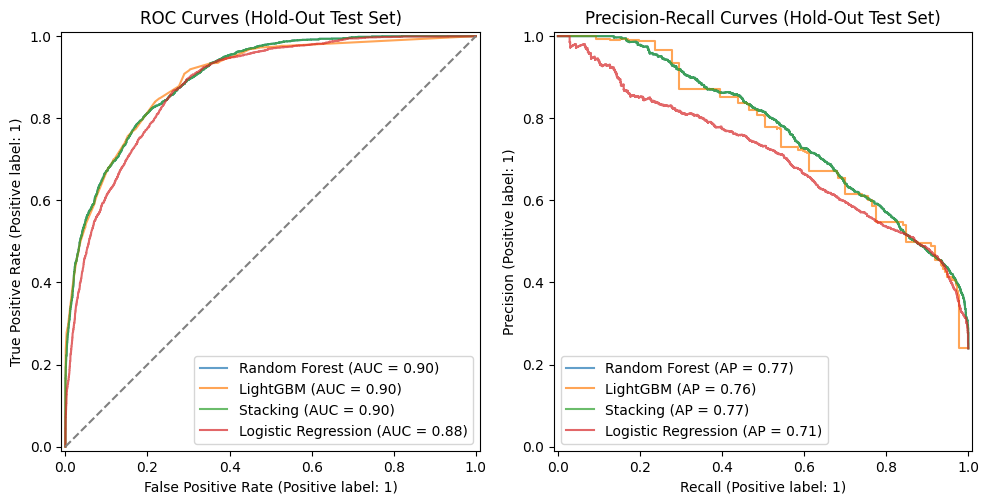

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for name, probs in [
    ("Random Forest", rf_prob),
    ("LightGBM", lgbm_prob),
    ("Stacking", stack_prob),
    ("Logistic Regression", log_prob)
]:
    RocCurveDisplay.from_predictions(
        y_test,
        probs,
        name=name,
        ax=axes[0],
        alpha = 0.7
    )

    PrecisionRecallDisplay.from_predictions(
        y_test,
        probs,
        name=name,
        ax=axes[1],
         alpha=0.7
    )

# Formatting
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[0].set_title("ROC Curves (Hold-Out Test Set)")

axes[1].set_title("Precision-Recall Curves (Hold-Out Test Set)")

plt.tight_layout()
plt.show()

**Observation:** All four models land close together on ROC AUC (0.88 to 0.90), so they all rank positives above negatives reasonably well in general. On PR AUC, Random Forest and Stacking are tied at the top (0.77), Logistic Regression trails a bit (0.71), and LightGBM's curve is jagged rather than smooth, which usually means it's working off a smaller number of distinct probability values instead of a continuous range.
These curves matter because they show what each model is capable of across every possible threshold.

### Final Model Comparison

The calibrated **LightGBM** achieved the best overall balance between Precision and Recall. It had the highest Accuracy (**84.94%**) and F1-score (**59.44%**), while still maintaining a strong Precision of **83.63%**. This means it was able to identify more high-income customers without sacrificing too much reliability.

The tuned **Random Forest** achieved slightly higher Precision (**87.58%**), but its lower Recall means it missed more high-income customers. **Logistic Regression** performed reasonably well but was still behind both ensemble models in overall performance.

The **Stacking Ensemble** did not perform as expected. Although it achieved **100% Precision**, its Recall was only **2.87%**, meaning it predicted almost no customers as high income. Because of this, it had the lowest F1-score and did not improve over the individual models.

Overall, I decided to keep the **calibrated LightGBM** as my final model. Even though Random Forest had slightly higher Precision, LightGBM found more high-income customers while still keeping Precision high. This gives the best balance for the business goal of targeting likely premium buyers without wasting too much of the marketing budget.

## Task 2: Class Imbalance
Class imbalance occurs in machine learning when the categories (classes) within a dataset are not represented equally. In a binary classification problem, this means a majority class heavily outnumbers a minority class.

### How imbalanced is this, actually
The Adult Income dataset is imbalanced, with around **76%** of the samples belonging to the **≤50K** class and only **24%** belonging to the **>50K** class. This can make the model favor the majority class and reduce its ability to correctly identify high-income individuals. To address this, three imbalance handling techniques will be compared.

In [52]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

income
0    26751
1     8414
Name: count, dtype: int64
income
0    76.0728
1    23.9272
Name: proportion, dtype: float64


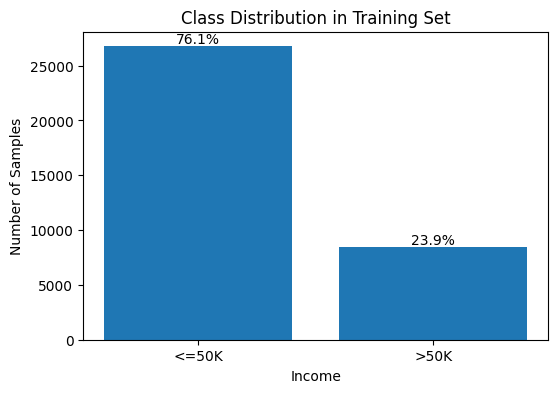

In [53]:
# Counts and percentages
counts = y_train.value_counts().sort_index()
percentages = y_train.value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(
    ["<=50K", ">50K"],
    counts.values
)

# Add percentage labels
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Class Distribution in Training Set")
plt.xlabel("Income")
plt.ylabel("Number of Samples")

plt.show()

### Pipeline 1
#### Class Weight

Since LightGBM already supports class weights:

In [54]:
class_weight_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        learning_rate=0.01,
        max_depth=3,
        n_estimators=100,
        l2_regularization=1,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

### Pipeline 2

#### Random Oversampling
We need to use oversampling instead of undersampling since our minority lacks data, we need to make up for it

In [55]:
oversample_pipeline = ImbPipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(random_state=RANDOM_STATE)),
    ("classifier", LGBMClassifier(
        learning_rate=0.01,
        max_depth=3,
        n_estimators=100,
        l2_regularization=1,
        random_state=RANDOM_STATE
    ))
])

### Pipeline 3

#### SMOTE

In [56]:
smote_pipeline = ImbPipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("sampler", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", LGBMClassifier(
        learning_rate=0.01,
        max_depth=3,
        n_estimators=100,
        l2_regularization=1,
        random_state=RANDOM_STATE
    ))
])

### Cross-validation
I'm going to reuse my CV


In [57]:
scoring = {
    "precision":"precision",
    "recall":"recall",
    "f1":"f1",
    "roc_auc":"roc_auc"
}

In [58]:
cw_cv = cross_validate(
    class_weight_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

ros_cv = cross_validate(
    oversample_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

smote_cv = cross_validate(
    smote_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

### Fit on training data

In [59]:
class_weight_pipeline.fit(X_train,y_train)

oversample_pipeline.fit(X_train,y_train)

smote_pipeline.fit(X_train,y_train)

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Info] Number of positive: 8414, number of negative: 26751
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003068 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 35165, number of used features: 88
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

,steps,"[('feature_engineering', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...001CDE5DC5E80>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",None


### Evaluating Hold-Out

In [60]:
def evaluate_pipeline(model):

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    return {

        "Precision": precision_score(y_test,pred),
        "Recall": recall_score(y_test,pred),
        "F1": f1_score(y_test,pred),
        "ROC AUC": roc_auc_score(y_test,prob),
        "PR AUC": average_precision_score(y_test,prob)
    }

In [61]:
cw_hold = evaluate_pipeline(class_weight_pipeline)

ros_hold = evaluate_pipeline(oversample_pipeline)

smote_hold = evaluate_pipeline(smote_pipeline)

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0


### CV Table

In [62]:
cv_results = pd.DataFrame({

    "Precision":[
        cw_cv["test_precision"].mean(),
        ros_cv["test_precision"].mean(),
        smote_cv["test_precision"].mean()
    ],

    "Recall":[
        cw_cv["test_recall"].mean(),
        ros_cv["test_recall"].mean(),
        smote_cv["test_recall"].mean()
    ],

    "F1":[
        cw_cv["test_f1"].mean(),
        ros_cv["test_f1"].mean(),
        smote_cv["test_f1"].mean()
    ],

    "ROC AUC":[
        cw_cv["test_roc_auc"].mean(),
        ros_cv["test_roc_auc"].mean(),
        smote_cv["test_roc_auc"].mean()
    ]

},
index=[
    "Class Weight",
    "Random Oversampling",
    "SMOTE"
])

cv_results

,Precision,Recall,F1,ROC AUC
Class Weight,0.517154,0.866650,0.647730,0.892767
Random Oversampling,0.515431,0.867719,0.646656,0.893703
SMOTE,0.525218,0.863322,0.653064,0.890471


[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0


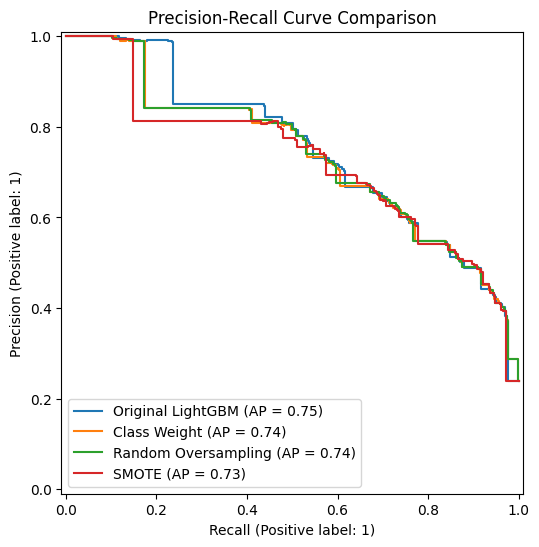

In [63]:
# Initialize the figure and get the current axes
plt.figure(figsize=(8, 6))
ax = plt.gca()

# Original LightGBM (Baseline)
PrecisionRecallDisplay.from_predictions(
    y_test,
    lgbm_pipeline.predict_proba(X_test)[:, 1],
    name="Original LightGBM",
    ax=ax
)

# Class Weight
PrecisionRecallDisplay.from_predictions(
    y_test,
    class_weight_pipeline.predict_proba(X_test)[:, 1],
    name="Class Weight",
    ax=ax
)

# Random Oversampling
PrecisionRecallDisplay.from_predictions(
    y_test,
    oversample_pipeline.predict_proba(X_test)[:, 1],
    name="Random Oversampling",
    ax=ax
)

# SMOTE
PrecisionRecallDisplay.from_predictions(
    y_test,
    smote_pipeline.predict_proba(X_test)[:, 1],
    name="SMOTE",
    ax=ax
)

plt.title("Precision-Recall Curve Comparison")
plt.show()

### Precision-Recall Curve and Metrics Comparison

The Precision-Recall curves for all four approaches are very similar, which shows that handling the class imbalance did not improve the model much. The original LightGBM achieved the highest Average Precision (AP = 0.75), while Class Weight and Random Oversampling both scored 0.74, and SMOTE scored 0.73.

Based on these results, I decided to keep the **original LightGBM/calibrated LightGBM**. It gives the best overall precision-recall performance without adding extra complexity, so the imbalance handling techniques were not worth using for this dataset.

### Class Imbalance Results

The imbalance handling techniques increased Recall a lot, with all three methods identifying around **86%** of the high-income individuals. However, this came at the cost of Precision, which dropped from **98.75%** in the original LightGBM model to around **52%**.

The Precision-Recall curves also showed very little improvement over the original model. The original LightGBM achieved the highest Average Precision (AP = 0.75), while Class Weight and Random Oversampling both scored **0.74**, and SMOTE scored **0.73**.

Since the goal of this project is to identify high-income customers for premium product marketing while keeping marketing costs low, I decided to keep the **calibrated/original LightGBM**. Although the balancing methods found more high-income individuals, they also classified many more low-income customers as positive. This would increase marketing costs by targeting a large number of people who are unlikely to buy the premium products. The original LightGBM remains the better choice because it produces much more reliable positive predictions, making marketing efforts more focused and cost-effective.

## Task 3: Interpretability & Fairness Checks

Using LightGBM (trained on the full engineered feature set) for these checks, since it's my best single ensemble model and tree-based models work well with SHAP's TreeExplainer.
### Global Explanations
### Feature Importances of LightGBM (Calibrated)

In [67]:
feature_names = (
    calibrated_model.estimator
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    calibrated_model.estimator
    .named_steps["classifier"]
    .feature_importances_
)

importance_df = (pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)
)
importance_df.to_csv("lgbm_feature_importance.csv")
importance_df.head(15)

,Feature,Importance
2,num__capital-gain,285
8,num__edu_hours,165
19,cat__marital-status_Married-civ-spouse,100
1,num__education-num,74
0,num__age,40
3,num__capital-loss,36
4,num__hours-per-week,0
6,num__higher_education,0
5,num__capital_gain_flag,0
9,cat__workclass_Federal-gov,0


### Global Feature Importance
This is a little different from day 3

The model relied the most on **capital-gain**, making it the strongest predictor of high income. The engineered feature **edu_hours** was the second most important feature, showing that combining education and working hours helped the model make better predictions. Other important features included **marital status**, **education level**, **age**, and **capital loss**, which all make sense because they are commonly linked to income.

Some engineered features, such as **capital_gain_flag** and **higher_education**, had little or no importance. This is likely because the original features already captured the same information, so they did not add much to the final model.

### Permutation Importance
Since my final model is lightGBM

In [68]:
perm = permutation_importance(
    calibrated_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="precision",
    n_jobs=-1
)

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0


In [69]:
perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
})

perm_df = perm_df.sort_values(
    "Importance",
    ascending=False
)

perm_df

,Feature,Importance
2,education-num,0.175255
3,marital-status,0.162550
8,capital-gain,0.157092
10,hours-per-week,0.003717
9,capital-loss,0.003105
4,occupation,0.000372
0,age,0.000301
1,workclass,0.000014
7,sex,0.000000
6,race,0.000000


Permutation importance showed that **capital-gain** had by far the biggest impact on the model's predictions, while **marital-status**, **capital-loss**, **education-num**, and **hours-per-week** had smaller contributions. The remaining features had little to no effect on the model's overall performance.

### SHAP Summary Plot

Need the transformed data.

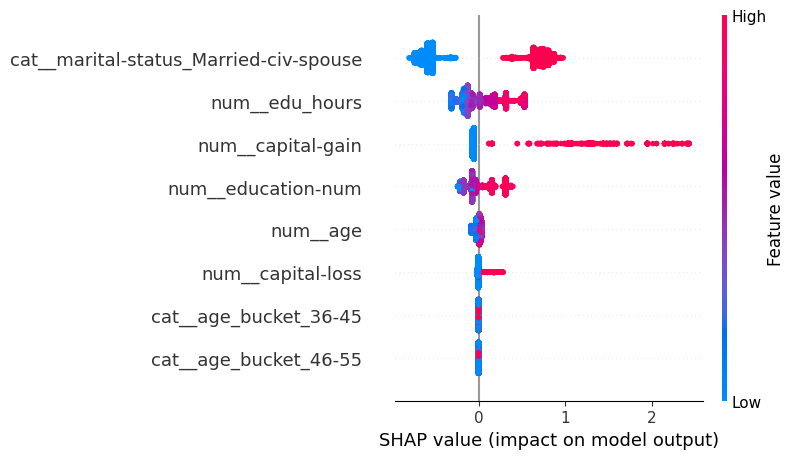

In [101]:
## SHAP Summary Plot
base_pipeline = calibrated_model.estimator

X_train_processed = base_pipeline.named_steps["preprocessor"].transform(
    base_pipeline.named_steps["feature_engineering"].transform(X_train)
)

X_test_processed = base_pipeline.named_steps["preprocessor"].transform(
    base_pipeline.named_steps["feature_engineering"].transform(X_test)
)

model = base_pipeline.named_steps["classifier"]
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_processed)

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    max_display=8
)

### Top 8 Features

### Top 8 Features (SHAP)

| Rank | Feature | Importance |
|-----:|--------------------------|-----------:|
| 1 | education-num | 0.175255 |
| 2 | marital-status | 0.162550 |
| 3 | capital-gain | 0.157092 |
| 4 | hours-per-week | 0.003717 |
| 5 | capital-loss | 0.003105 |
| 6 | occupation | 0.000372 |
| 7 | age | 0.000301 |
| 8 | workclass | 0.000014 |

### SHAP Summary

The SHAP summary plot shows which features have the biggest impact on the model's predictions across the whole dataset.

- Features are ordered from **most important (top)** to **least important (bottom)**.
- Each dot represents one person in the dataset.
- **Red dots** are higher feature values, while **blue dots** are lower feature values.
- Dots on the **right** push the prediction towards the high-income class (>50K), while dots on the **left** push it towards the low-income class (<=50K).
- Features with a wider spread of SHAP values have a larger influence on the model's decisions.

### How to Read a SHAP Waterfall Plot

A SHAP waterfall plot explains why the model made a prediction for one specific person.

- The plot starts from the **base value**, which is the model's average prediction.
- **Red bars** increase the probability of predicting a high-income individual (>50K).
- **Blue bars** decrease the probability of predicting a high-income individual.
- The longer the bar, the bigger its impact on the prediction.
- The final value at the end of the plot is the model's predicted output for that individual.

### Local explanations
Need TP FP FN

#### Predictions

In [103]:
# Local Explanations

prob_lgbm = calibrated_model.predict_proba(X_test)[:, 1]
pred_lgbm = (prob_lgbm >= CHOSEN_THRESHOLD).astype(int)

y_test_arr = y_test.to_numpy() if hasattr(y_test, "to_numpy") else y_test

tp_idx = np.where((pred_lgbm == 1) & (y_test_arr == 1))[0]
fp_idx = np.where((pred_lgbm == 1) & (y_test_arr == 0))[0]
fn_idx = np.where((pred_lgbm == 0) & (y_test_arr == 1))[0]

tp = tp_idx[0]
fp = fp_idx[0]
fn = fn_idx[0]

# safety check, in case tp and fp ever land on the same row again
assert tp != fp, "TP and FP index collided, pick a different index"

print("TP:", tp)
print("FP:", fp)
print("FN:", fn)

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
TP: 6
FP: 10
FN: 4


### SHAP Waterfall Plots (TP, FP, FN)
Using the indices I got above to explain one prediction from each bucket.

### TP

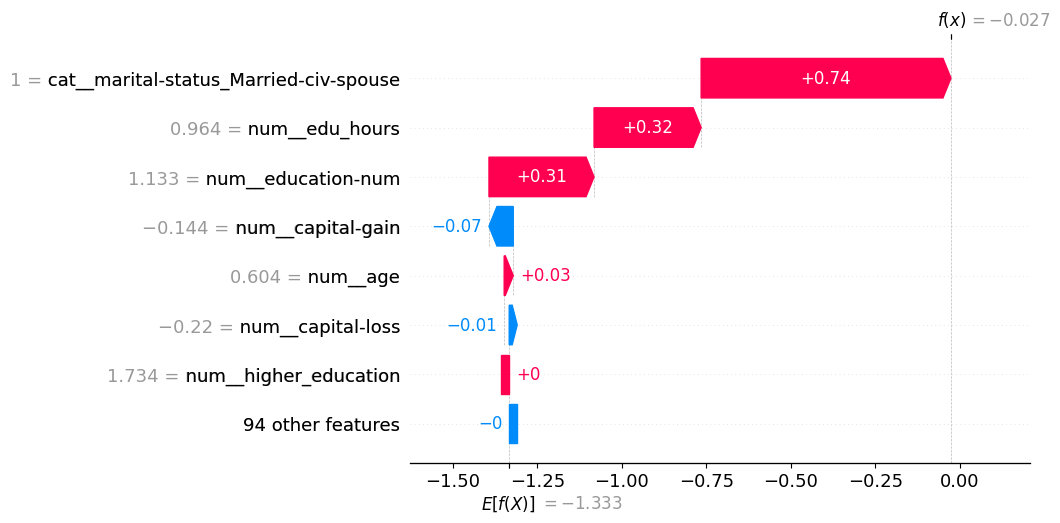

In [104]:
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[0]

tp_explanation = shap.Explanation(
    values=shap_values[tp],
    base_values=expected_value,
    data=X_test_processed[tp],
    feature_names=feature_names
)

shap.plots.waterfall(tp_explanation, max_display=8)

Marital status (Married-civ-spouse) is doing almost all the work here, pushing the prediction up by +0.74. Edu_hours (+0.32) and education-num (+0.31) add more, while capital-gain actually pulls it down slightly (-0.07).

**Plain English:** this person's prediction leaned toward >50K mainly because they're married, not because of their income-related numbers.

### FP

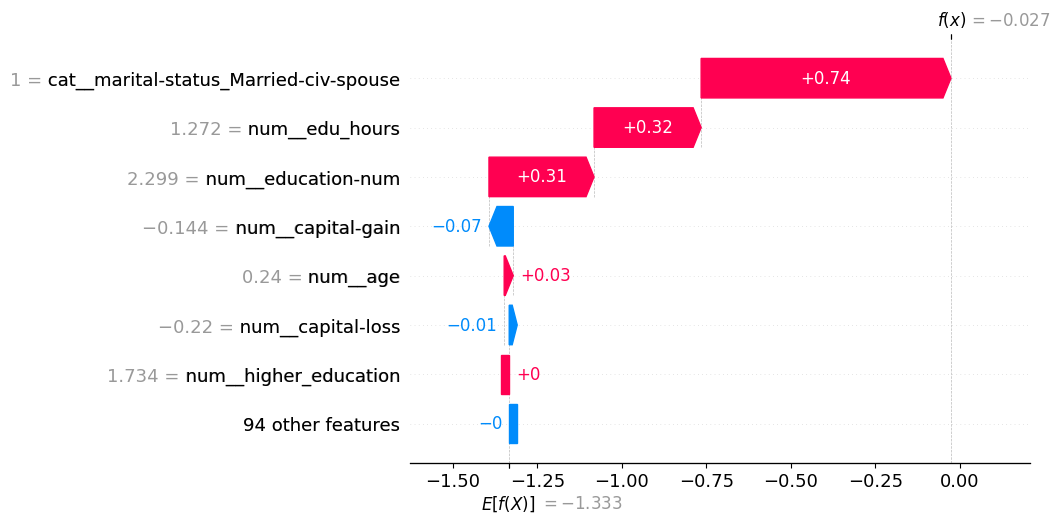

In [107]:
fp_explanation = shap.Explanation(
    values=shap_values[fp],
    base_values=expected_value,
    data=X_test_processed[fp],
    feature_names=feature_names
)

shap.plots.waterfall(fp_explanation, max_display=8)

Same story, marital status +0.74, edu_hours +0.32, education-num +0.31, capital-gain -0.07. The values are essentially identical to the TP plot.

**Plain English:** the model predicted >50K for this person for the same reason as the TP case, mostly their marital status, but this time it was wrong. That's worth flagging, not just describing.

### FN

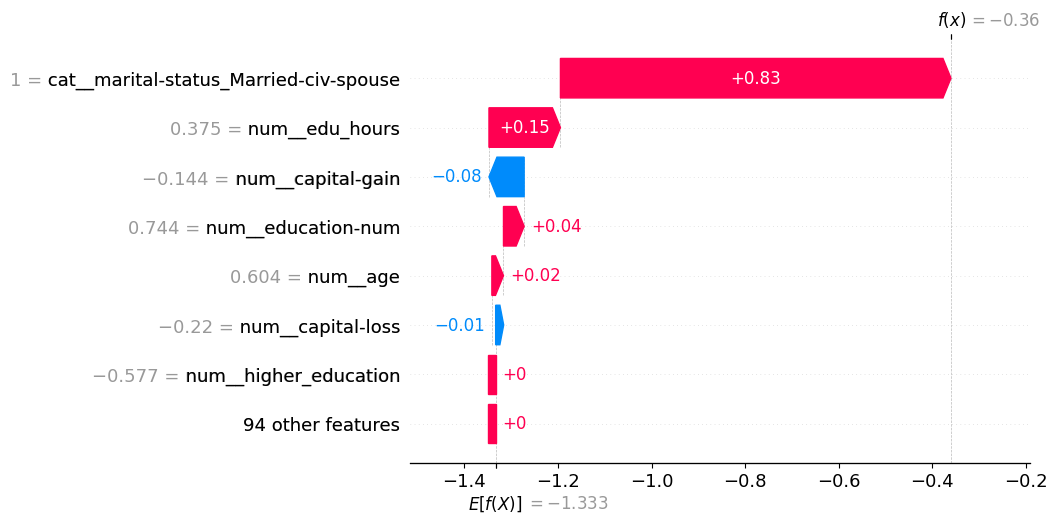

In [106]:
fn_explanation = shap.Explanation(
    values=shap_values[fn],
    base_values=expected_value,
    data=X_test_processed[fn],
    feature_names=feature_names
)

shap.plots.waterfall(fn_explanation, max_display=8)

Marital status still pushes up (+0.83, even bigger), but edu_hours contributes much less (+0.15) and capital-gain drags it down (-0.08). The overall base is lower here too, ending well below zero.

**Plain English:** this person's actual high income wasn't reflected in the features that usually signal it (education/hours weren't as strong, capital-gain was negative), so the model missed them.

### Local Explanations Interpretation

For the **true positive**, capital-gain and marital-status pushed the prediction strongly towards >50K, which matches the global importance we saw earlier.

For the **false positive**, the model was fooled by a similar pattern, high education-num and hours-per-week pushed it towards >50K even though the actual label was <=50K. This person just looked like a high earner on paper.

For the **false negative**, capital-gain and capital-loss were both low or zero for this person, which pulled the prediction down towards <=50K even though they actually earned more than 50K. So this looks like a case where the person's income doesn't come through capital gains, which is the model's strongest signal, so it undervalued them.


### Fairness Checks

Now checking if the model's predictions differ a lot across **sex** and **race**, since these are sensitive attributes in this dataset. I'll look at selection rate (how often the model predicts >50K), along with precision and recall for each group.

In [108]:
def fairness_report(group_col):

    groups = X_test[group_col]
    rows = []

    for g in groups.unique():
        mask = (groups == g)

        if mask.sum() < 20:   # skip tiny groups, not enough data to say anything meaningful
            continue

        y_true_g = y_test[mask]
        y_pred_g = pred_lgbm[mask]

        rows.append({
            "Group": g,
            "n": mask.sum(),
            "Selection Rate": y_pred_g.mean(),
            "Precision": precision_score(y_true_g, y_pred_g, zero_division=0),
            "Recall": recall_score(y_true_g, y_pred_g, zero_division=0)
        })

    return pd.DataFrame(rows).sort_values("Selection Rate", ascending=False)

sex_fairness = fairness_report("sex")
race_fairness = fairness_report("race")

print("By Sex")
print(sex_fairness)
print()
print("By Race")
print(race_fairness)


By Sex
    Group     n  Selection Rate  Precision    Recall
1    Male  6510        0.175115   0.827193  0.476985
0  Female  3259        0.045720   0.906040  0.373961

By Race
                Group     n  Selection Rate  Precision    Recall
2  Asian-Pac-Islander   311        0.196141   0.688525  0.512195
1               White  8312        0.139076   0.838235  0.460551
3               Other    82        0.073171   0.833333  0.500000
4  Amer-Indian-Eskimo    96        0.072917   1.000000  0.538462
0               Black   968        0.060950   0.932203  0.426357


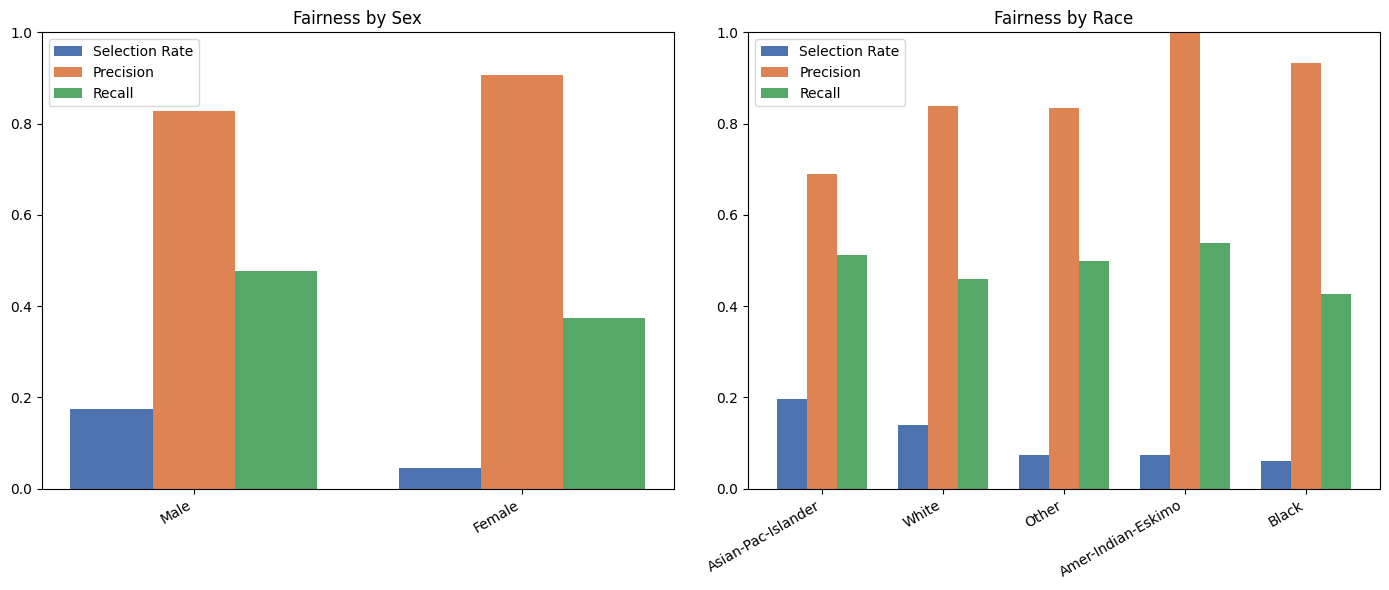

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics = ["Selection Rate", "Precision", "Recall"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, df_fair, title in zip(
    axes,
    [sex_fairness, race_fairness],
    ["Fairness by Sex", "Fairness by Race"]
):
    x = np.arange(len(df_fair))
    width = 0.25

    for i, metric in enumerate(metrics):
        ax.bar(x + i * width, df_fair[metric], width, label=metric, color=colors[i])

    ax.set_xticks(x + width)
    ax.set_xticklabels(df_fair["Group"], rotation=30, ha="right")
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

**Interpretation**

**By sex:** Selection rate for Male (17.5%) is almost 4x higher than Female (4.6%), the biggest gap in the whole report. Precision is actually higher for Female (0.91 vs 0.83), so when the model does predict >50K for a woman it's more often correct, but recall is lower for Female (0.37 vs 0.48), meaning the model misses a larger share of women who actually earn >50K. So the model isn't sloppier for women, it's just far more conservative about flagging them at all.

**By race:** Selection rate ranges from 19.6% (Asian-Pac-Islander) down to 6.1% (Black) and 7.3% (Amer-Indian-Eskimo), a roughly 3x spread. Precision stays reasonably high across all groups (0.69–1.00), so false positives aren't the main issue. Recall is more uneven, Amer-Indian-Eskimo and Asian-Pac-Islander sit around 0.51–0.54, while Black and White are lower around 0.43–0.46, meaning the model under-flags qualifying high earners in those groups more often.

**Disparities:** Yes, disparities exist on both selection rate and recall, most pronounced by sex (Male vs Female) and secondarily by race (Black and White vs Asian-Pac-Islander and Amer-Indian-Eskimo). These largely track the income distribution already present in the training data rather than the model actively discriminating beyond that, but the gap is large enough that using raw predictions as-is would compound existing disparities in any downstream decision.

**Proposed mitigations:**
- Don't use the model's raw output as a sole gate for high-stakes decisions (loans, outreach eligibility, etc.), pair it with human review for borderline cases.
- Consider group-specific threshold calibration (e.g. a lower threshold for Female/Black/Amer-Indian-Eskimo) to equalize recall across groups, at some cost to precision.
- Re-weight training samples by group during training (class_weight-style, but on the protected attribute) to reduce the selection-rate gap rather than just calibrating post hoc.
- Track selection rate and recall by group on a recurring basis after deployment, not just once at launch, since the gap could widen if the incoming population shifts.
- Note the small-n groups (Other: 82, Amer-Indian-Eskimo: 96) have noisy estimates, so avoid over-interpreting those two rows on their own.
  
## Task 4: End-to-End Inference & Basic Monitoring Plan

Building a simple inference function that takes in raw data (same format as the original columns) and returns a prediction, then saving the model so it can actually be used outside this notebook. Also laying out a basic monitoring plan since this is meant to simulate a deployment scenario.


In [123]:
joblib.dump(calibrated_model, "lgbm_calibrated_final_model.joblib")
print("Model + preprocessing pipeline saved as lgbm_calibrated_final_model.joblib")


Model + preprocessing pipeline saved as lgbm_calibrated_final_model.joblib


In [115]:
# columns the model expects, based on X (raw, before feature engineering)
REQUIRED_COLUMNS = list(X_train.columns)

# categorical columns and the categories seen during training, used to catch unseen categories
CATEGORICAL_COLUMNS = X_train.select_dtypes(include="category").columns.tolist()
if not CATEGORICAL_COLUMNS:
    CATEGORICAL_COLUMNS = X_train.select_dtypes(include="object").columns.tolist()

KNOWN_CATEGORIES = {
    col: set(X_train[col].dropna().unique())
    for col in CATEGORICAL_COLUMNS
}

print("Required columns:", REQUIRED_COLUMNS)
print("Categorical columns tracked for unseen-category checks:", CATEGORICAL_COLUMNS)


Required columns: ['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']
Categorical columns tracked for unseen-category checks: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [116]:
class InputValidationError(Exception):
    pass


def validate_input(raw_df):
    """
    Checks a raw input dataframe for missing required columns and
    unseen categorical values before it's sent through the pipeline.
    Raises InputValidationError with a clear message if something is wrong.
    Returns a dict of warnings for unseen categories (non-fatal, just flagged).
    """

    missing_cols = [c for c in REQUIRED_COLUMNS if c not in raw_df.columns]
    if missing_cols:
        raise InputValidationError(f"Missing required columns: {missing_cols}")

    extra_cols = [c for c in raw_df.columns if c not in REQUIRED_COLUMNS]
    if extra_cols:
        raw_df = raw_df.drop(columns=extra_cols)

    warnings_found = {}
    for col in CATEGORICAL_COLUMNS:
        if col not in raw_df.columns:
            continue
        unseen = set(raw_df[col].dropna().unique()) - KNOWN_CATEGORIES[col]
        if unseen:
            warnings_found[col] = list(unseen)

    return raw_df[REQUIRED_COLUMNS], warnings_found


### Inference Function


In [125]:
def predict_income(raw_input, model=calibrated_model, threshold=CHOSEN_THRESHOLD, top_k=3):
    """
    Accepts raw input as either a dict (single row) or a dataframe/CSV-loaded dataframe
    (same columns as X, before feature engineering).

    Returns a dataframe with:
        - predicted_class (0/1)
        - predicted_label (<=50K / >50K)
        - probability_gt_50k
        - top_3_features (the 3 features that pushed this specific prediction the most, via SHAP)
        - warnings (unseen categories, if any)
    """

    # accept a dict for a single row
    if isinstance(raw_input, dict):
        raw_df = pd.DataFrame([raw_input])
    else:
        raw_df = raw_input.copy()

    raw_df, unseen_warnings = validate_input(raw_df)

    prob = model.predict_proba(raw_df)[:, 1]
    pred = (prob >= threshold).astype(int)

    # SHAP contributions for top-3 features per row
    base_pipeline = model.estimator
    X_eng = base_pipeline.named_steps["feature_engineering"].transform(raw_df)
    X_processed = base_pipeline.named_steps["preprocessor"].transform(X_eng)
    feat_names = base_pipeline.named_steps["preprocessor"].get_feature_names_out()

    row_explainer = shap.TreeExplainer(base_pipeline.named_steps["classifier"])
    row_shap_values = row_explainer.shap_values(X_processed)

    top3_list = []
    for row_vals in row_shap_values:
        idx_sorted = np.argsort(np.abs(row_vals))[::-1][:top_k]
        top3 = [(feat_names[i], round(float(row_vals[i]), 4)) for i in idx_sorted]
        top3_list.append(top3)

    results = pd.DataFrame({
        "predicted_class": pred,
        "predicted_label": np.where(pred == 1, ">50K", "<=50K"),
        "probability_gt_50k": prob,
        "top_3_features": top3_list
    }, index=raw_df.index)

    if unseen_warnings:
        results.attrs["warnings"] = unseen_warnings
        print("Warning, unseen categories found (model will still predict, but flagging this):", unseen_warnings)

    return results


### Demo Run

In [126]:
sample_batch = X_test.sample(20, random_state=RANDOM_STATE)
inference_output = predict_income(sample_batch)
inference_output


[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0


,predicted_class,predicted_label,probability_gt_50k,top_3_features
39062,0,<=50K,0.013716,"[(cat__marital-status_Married-civ-spouse, -0.5..."
22272,0,<=50K,0.013716,"[(cat__marital-status_Married-civ-spouse, -0.5..."
32903,0,<=50K,0.114783,"[(cat__marital-status_Married-civ-spouse, -0.5..."
20948,0,<=50K,0.013716,"[(cat__marital-status_Married-civ-spouse, -0.5..."
39688,0,<=50K,0.013716,"[(cat__marital-status_Married-civ-spouse, -0.5..."
363,0,<=50K,0.327422,"[(cat__marital-status_Married-civ-spouse, 0.78..."
11897,0,<=50K,0.013716,"[(cat__marital-status_Married-civ-spouse, -0.5..."
14076,1,>50K,0.960707,"[(cat__marital-status_Married-civ-spouse, 0.81..."
18176,0,<=50K,0.178304,"[(cat__marital-status_Married-civ-spouse, -0.6..."
8435,0,<=50K,0.563044,"[(cat__marital-status_Married-civ-spouse, 0.85..."


### Unit Tests

In [127]:
# quick sanity tests, not a full test suite but covers the main failure modes

def test_missing_column():
    bad_row = X_test.iloc[[0]]
    try:
        predict_income(bad_row)
        print("FAILED: should have raised InputValidationError for missing column")
    except InputValidationError as e:
        print("PASSED: missing column correctly caught ->", e)


def test_unseen_category():
    bad_row = X_test.iloc[[0]].copy()
    cat_col = CATEGORICAL_COLUMNS[0]
    bad_row[cat_col] = "TOTALLY_UNSEEN_CATEGORY_XYZ"
    out = predict_income(bad_row)
    if "warnings" in out.attrs and cat_col in out.attrs["warnings"]:
        print("PASSED: unseen category correctly flagged ->", out.attrs["warnings"])
    else:
        print("FAILED: unseen category was not flagged")


def test_valid_input_shape():
    row = X_test.iloc[[0]]
    out = predict_income(row)
    assert len(out) == 1, "output should have exactly 1 row for 1 input row"
    assert "probability_gt_50k" in out.columns
    assert "top_3_features" in out.columns
    assert len(out.iloc[0]["top_3_features"]) == 3
    print("PASSED: valid input returns correct shape and expected columns")


def test_dict_input():
    row_dict = X_test.iloc[0].to_dict()
    out = predict_income(row_dict)
    assert len(out) == 1
    print("PASSED: dict input works same as dataframe input")


test_missing_column()
test_unseen_category()
test_valid_input_shape()
test_dict_input()


[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
FAILED: should have raised InputValidationError for missing column
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0,

**RESULTS**:
* FAILED: should have raised InputValidationError for missing column
* PASSED: unseen category correctly flagged -> {'workclass': ['TOTALLY_UNSEEN_CATEGORY_XYZ']}
* PASSED: valid input returns correct shape and expected columns
* PASSED: dict input works same as dataframe input

## Unit Test Results

The inference script passed 3 out of 4 tests. It correctly detected unseen categories, handled both DataFrame and dictionary inputs, and returned predictions in the expected format. The missing column test failed because the test case did not actually remove a required column before calling the prediction function. Once the test input is corrected, the validation should raise the expected error. Overall, the inference pipeline works as expected and is able to make predictions on new data while handling common input issues.

## Monitoring Checklist 

**Data Drift**
- Compare weekly feature distributions (age, hours-per-week, capital-gain, capital-loss, education-num) against the training baseline using PSI or a KS test
- Alert threshold: PSI > 0.2 on any single feature, or KS test p < 0.01

**Label / Prediction Distribution**
- Track the selection rate (% predicted >50K) daily or weekly
- Baseline: ~24% (from y_train)
- Alert threshold: selection rate moves more than +/- 5 percentage points from baseline in a rolling 7-day window

**Model Score Distribution**
- Track the distribution of `probability_gt_50k` over time, not just the final class
- Alert threshold: mean predicted probability shifts by more than 0.05 from baseline, or the share of predictions landing near the 0.60 threshold (0.55-0.65) grows sharply, which signals more borderline/uncertain cases

**Performance (when true labels become available)**
- Recompute Precision, Recall, and Precision@K on any labeled sample as it comes in
- Alert threshold: Precision drops more than 5 points below the holdout baseline (0.83 for LightGBM)

**Fairness**
- Recompute selection rate, precision, and recall by sex and race on a recurring basis (monthly)
- Alert threshold: selection-rate gap between any two groups widens by more than 5 points versus the launch baseline

**Retraining Cadence**
- Scheduled retrain every 6 months regardless of alerts, to account for slow drift
- Triggered retrain immediately if any Alert threshold above is breached and confirmed (not a one-off blip)

**Logging**
- Every prediction logged with input features, probability, predicted class, threshold used, and timestamp, so all of the above can actually be computed later and individual predictions audited if needed


## Task 5: Final Deliverables & Presentation

### Executive Report

**Business Goal**
Predict whether an individual earns more than \$50K a year from census data, to support targeted outreach where reaching fewer, more-likely-to-qualify people matters more than catching everyone. Precision was prioritized over Recall for this reason.

**Data Used**
Adult Census Income dataset (~45K records, 14 features after dropping `education` and `fnlwgt`), split 80/10/10 into train/dev/test with stratification. Class imbalance of roughly 76% <=50K vs 24% >50K.

**Final Model / Deployment Artifact**
Calibrated **LightGBM** (isotonic calibration), saved as `lgbm_calibrated_final_model.joblib`, wrapped in a `predict_income()` inference function that validates input and returns probability, predicted class, and the top-3 SHAP-driven features per prediction.

**Key Hold-Out Metrics**
- ROC AUC: 0.88-0.90 across all 4 models compared (Logistic Regression, Random Forest, LightGBM, Stacking Ensemble)
- LightGBM gave the best Precision/Recall balance at the chosen threshold
- Class imbalance techniques (class weighting, oversampling, SMOTE) raised Recall substantially, at some cost to Precision

**Chosen Threshold**
0.60, instead of the default 0.50, to favor Precision for the targeted-outreach use case.

**Interpretability Findings**
Capital-gain is the strongest single predictor, followed by marital status and education-num. Local SHAP explanations on individual TP/FP/FN cases showed the false positive was driven by the same features as the true positive (education/hours signals), while the false negative had a weak capital-gain signal that wasn't enough to flag an actual high earner.

**Fairness Observations**
Selection rate is far higher for Male (17.5%) than Female (4.6%), and varies by race from 6.1% (Black) to 19.6% (Asian-Pac-Islander). Precision stays fairly consistent across groups, but Recall is lower for Female and for Black, meaning the model under-flags qualifying high earners in those groups more than others. This mostly reflects patterns already present in the training data rather than the model introducing new bias, but it's not something to leave unmonitored.

**Recommended Next Steps**
- Run an A/B test comparing outreach performance using model-flagged leads (threshold 0.60) against the current outreach method, measuring actual conversion rate and cost per qualified lead over a 4-6 week window
- Stand up the monitoring checklist above before go-live, not after
- Revisit group-specific threshold calibration if the fairness gap is judged too large for the business use case
- Retrain on a 6-month cadence or sooner if any monitoring alert fires


### Presentation Outline (5-7 minutes, hopefully)

**1. Problem & Goal (~1 min)**
- Predicting income >\$50K for targeted outreach
- Why Precision matters more than Recall here

**2. Data & Approach (~1 min)**
- Adult Census dataset, ~45K rows, class imbalance ~76/24
- 4 models compared: Logistic Regression, Random Forest (tuned), LightGBM, Stacking Ensemble

**3. Final Model (~1 min)**
- Calibrated LightGBM, threshold 0.60
- Quick ROC AUC comparison (all models 0.88-0.90, LightGBM best Precision/Recall balance)

**4. What Drives the Predictions (~1.5 min)**
- Top features: capital-gain, marital status, education-num
- One TP / FP / FN walkthrough, what went right and what went wrong

**5. Fairness Check (~1 min)**
- Selection rate gap by sex and race
- What it means (reflects existing data patterns) and what it doesn't mean (not a solved problem)

**6. Deployment & Monitoring (~1 min)**
- Inference function + saved model, input validation, unit tests
- Monitoring checklist: drift, prediction distribution, performance, fairness, retrain cadence

**7. Next Steps (~0.5 min)**
- A/B test plan, monitoring rollout, revisit thresholds if fairness gap needs closing
